#### Setup and Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

plt.style.use('dark_background')
sns.set_palette("viridis")

df = pd.read_csv('data/raw/romina_coffee_traceability_master.csv')

print(f"Analysis Engine Ready. Processing {len(df)} plots.")

Analysis Engine Ready. Processing 2000 plots.


#### The "Risk Heatmap" (Regional Breakdown)

In [9]:
df['is_non_compliant'] = pd.to_datetime(df['last_deforestation_event']) > pd.Timestamp('2020-12-31')

risk_summary = df.groupby(['region', 'woreda']).agg({
    'is_non_compliant': 'sum',
    'farmer_id': 'count',
    'eudr_readiness_score': 'mean'
}).rename(columns={'is_non_compliant': 'failed_plots', 'farmer_id': 'total_plots'})

risk_summary['failure_rate_%'] = (risk_summary['failed_plots'] / risk_summary['total_plots'] * 100).round(2)

csv_risk_path = 'outputs/reports/03_woreda_risk_table.csv'
risk_summary.to_csv(csv_risk_path)
print(f"Risk Table saved to: {csv_risk_path}")

print("--- TOP 5 RISK AREAS (Woredas) ---")
print(risk_summary.sort_values('failure_rate_%', ascending=False).head())

Risk Table saved to: outputs/reports/03_woreda_risk_table.csv
--- TOP 5 RISK AREAS (Woredas) ---
                            failed_plots  total_plots  eudr_readiness_score  \
region         woreda                                                         
Sidama         Aroresa                13          231             92.999134   
               Bensa                  12          221             93.931222   
               Bona Zuria             11          209             92.829665   
South Ethiopia Gedeb                   9          182             94.477473   
               Yirgacheffe             7          173             93.826012   

                            failure_rate_%  
region         woreda                       
Sidama         Aroresa                5.63  
               Bensa                  5.43  
               Bona Zuria             5.26  
South Ethiopia Gedeb                  4.95  
               Yirgacheffe            4.05  


#### Plot Size vs. Compliance (The Smallholder Challenge)

Static Plot saved to: outputs/viz/01_plot_size_compliance_scatter.png


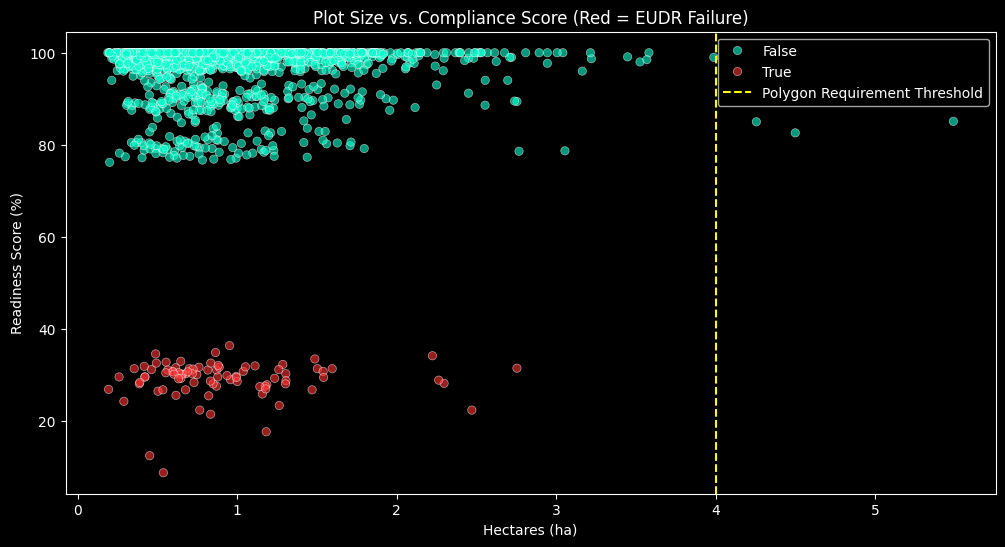

In [6]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='plot_size_ha', y='eudr_readiness_score', 
                hue='is_non_compliant', palette={True: '#FF3131', False: '#00FFCC'}, 
                alpha=0.6)

plt.axvline(4.0, color='yellow', linestyle='--', label='Polygon Requirement Threshold')
plt.title('Plot Size vs. Compliance Score (Red = EUDR Failure)')
plt.xlabel('Hectares (ha)')
plt.ylabel('Readiness Score (%)')
plt.legend()

plt_save_path = 'outputs/viz/01_plot_size_compliance_scatter.png'
plt.savefig(plt_save_path, dpi=300, bbox_inches='tight')
print(f"Static Plot saved to: {plt_save_path}")

plt.show()

#### Altitude and Quality Potential

Interactive Fig saved to: outputs/viz/02_altitude_quality_analysis.html


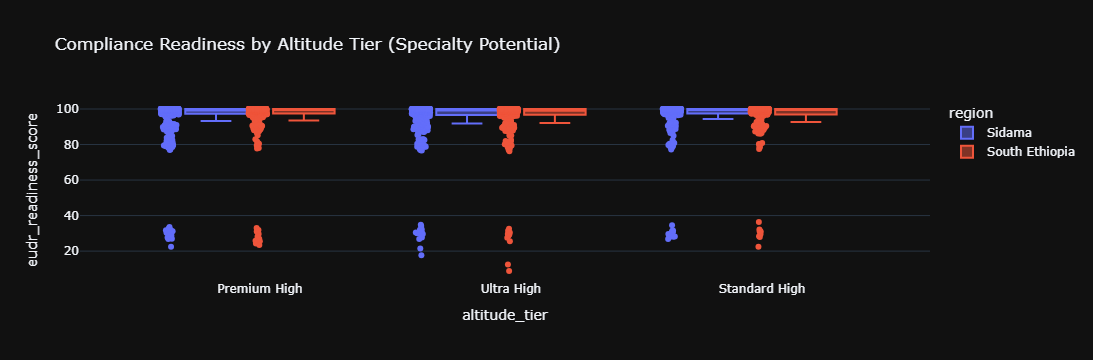

In [7]:
df['altitude_tier'] = pd.cut(df['altitude_masl'], 
                             bins=[1800, 1950, 2100, 2300], 
                             labels=['Standard High', 'Premium High', 'Ultra High'])

fig = px.box(df, x='altitude_tier', y='eudr_readiness_score', 
             color='region', points="all",
             title="Compliance Readiness by Altitude Tier (Specialty Potential)",
             template="plotly_dark")

plotly_save_path = 'outputs/viz/02_altitude_quality_analysis.html'
fig.write_html(plotly_save_path)
print(f"Interactive Fig saved to: {plotly_save_path}")

fig.show()

#### Preparing Data for the Dashboard

In [5]:
processed_path = 'data/processed/romina_compliance_final.csv'
df.to_csv(processed_path, index=False)

print(f"EDA Complete. Processed file saved at {processed_path}")

EDA Complete. Processed file saved at data/processed/romina_compliance_final.csv


In [11]:
import os
import pandas as pd

current_dir = os.getcwd()

if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

processed_dir = os.path.join(project_root, 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

final_file_path = os.path.join(processed_dir, 'romina_compliance_final.csv')

df.to_csv(final_file_path, index=False)

print(f"Success! File saved at: {final_file_path}")
print("Now, go to your Streamlit tab and press 'R' to refresh.")

Success! File saved at: C:\Users\tohiba\Desktop\eudr-coffee-traceability-romina\data\processed\romina_compliance_final.csv
Now, go to your Streamlit tab and press 'R' to refresh.
